# Synthetic Data Verification

Two extreme synthetic datasets are fitted with a single-cluster Tied Mallows model:

1. **Identical rankings** — every assessor reports the exact same strict ranking `0 > 1 > 2 > … > n-1`. The MAP consensus should recover that ranking perfectly and θ should be high.
2. **Uniform-random rankings** — each assessor reports an independent uniformly-random permutation, so every item is preferred equally to every other item. The MAP consensus should put everything in one big block and θ should be near zero.

Pairwise preference matrices are shown first to confirm the datasets are correct, then the MCMC results are displayed.

In [6]:
import sys
sys.path.insert(0, ".")

import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from model import MixtureRankingModel
from model.dataclasses import ClusterParams

## Dataset parameters

In [3]:
N_ITEMS  = 8     # number of items to rank
N_PAIRS  = 50    # number of (permutation, reverse) pairs → N_PAIRS*2 total raters
SEED     = 42

# ── Dataset 1: identical strict rankings ─────────────────────────────────────
true_ranking = list(range(N_ITEMS))       # 0 is best, N_ITEMS-1 is worst
N_RATERS = N_PAIRS * 2
dataset_identical = [true_ranking[:] for _ in range(N_RATERS)]

# ── Dataset 2: exactly balanced random rankings ───────────────────────────────
# For every random permutation we also include its reverse.
# This guarantees P(i preferred over j) = exactly 0.5 for every off-diagonal
# pair (i, j): whenever i beats j in the forward permutation, j beats i in
# the reversed one, so the counts cancel perfectly.
rng = random.Random(SEED)
dataset_random = []
for _ in range(N_PAIRS):
    perm = list(range(N_ITEMS))
    rng.shuffle(perm)
    dataset_random.append(perm)
    dataset_random.append(list(reversed(perm)))   # exact reverse → cancels pairwise preferences

print(f"N_ITEMS={N_ITEMS}, N_RATERS={len(dataset_random)} (={N_PAIRS} paired permutations)")
print(f"Example paired permutations:")
print(f"  forward : {dataset_random[0]}")
print(f"  reverse : {dataset_random[1]}")


N_ITEMS=8, N_RATERS=100 (=50 paired permutations)
Example paired permutations:
  forward : [3, 4, 6, 7, 2, 5, 0, 1]
  reverse : [1, 0, 5, 2, 7, 6, 4, 3]


## Pairwise preference matrices

Cell $(i, j)$ shows the fraction of rankings in which item $i$ is ranked **above** (preferred to) item $j$.

* **Identical rankings** → upper triangle all 1, lower triangle all 0 (perfect order).
* **Random rankings** → every cell ≈ 0.5 (no preference).

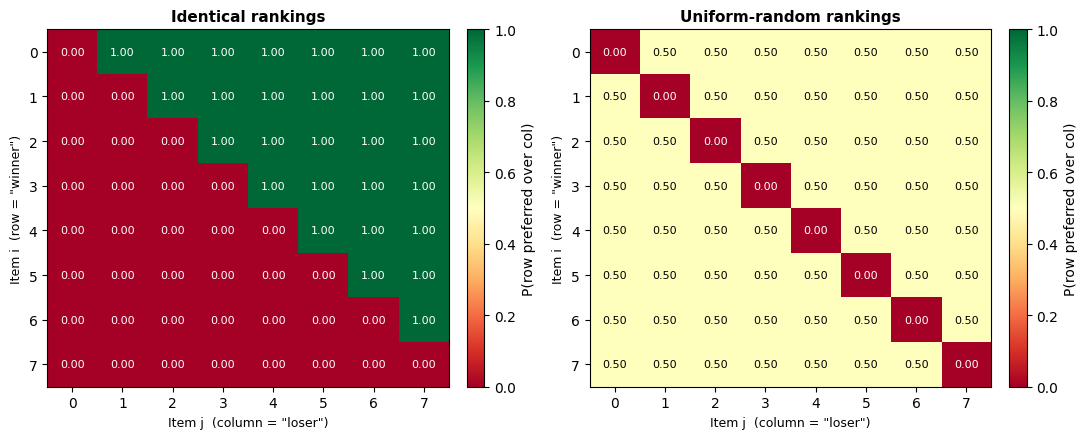

Identical  — off-diagonal range: [0.000, 1.000]
Random     — off-diagonal range: [0.500, 0.500]
Random     — mean ± std         : 0.500 ± 0.000


In [20]:
def pairwise_preference(rankings, n_items):
    """Return matrix P where P[i,j] = fraction of rankings ranking i above j."""
    P = np.zeros((n_items, n_items))
    for r in rankings:
        pos = {item: p for p, item in enumerate(r)}
        for i in range(n_items):
            for j in range(n_items):
                if i != j and pos[i] < pos[j]:
                    P[i, j] += 1
    P /= len(rankings)
    return P


P_identical = pairwise_preference(dataset_identical, N_ITEMS)
P_random    = pairwise_preference(dataset_random,    N_ITEMS)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, P, title in zip(
    axes,
    [P_identical, P_random],
    ["Identical rankings", "Uniform-random rankings"],
):
    im = ax.imshow(P, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="P(row preferred over col)", fraction=0.046, pad=0.04)
    for i in range(N_ITEMS):
        for j in range(N_ITEMS):
            ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="black" if 0.25 < P[i, j] < 0.75 else "white")
    labels = [str(k) for k in range(N_ITEMS)]
    ax.set_xticks(range(N_ITEMS)); ax.set_xticklabels(labels)
    ax.set_yticks(range(N_ITEMS)); ax.set_yticklabels(labels)
    ax.set_xlabel("Item j  (column = \"loser\")", fontsize=9)
    ax.set_ylabel("Item i  (row = \"winner\")", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")

fig.tight_layout()
plt.show()

# Numeric summary
off_diag_id  = P_identical[~np.eye(N_ITEMS, dtype=bool)]
off_diag_rnd = P_random   [~np.eye(N_ITEMS, dtype=bool)]
print(f"Identical  — off-diagonal range: [{off_diag_id.min():.3f}, {off_diag_id.max():.3f}]")
print(f"Random     — off-diagonal range: [{off_diag_rnd.min():.3f}, {off_diag_rnd.max():.3f}]")
print(f"Random     — mean ± std         : {off_diag_rnd.mean():.3f} ± {off_diag_rnd.std():.3f}")

## MCMC helper

In [4]:
import time

N_ITER  = 10_000
BURN_IN = 5_000

def run_single_cluster(rankings, n_items, label, *, seed=0):
    """Fit a single-cluster Tied Mallows model and return the MAP result."""
    # Borda initialisation: order items by total wins and start with singleton blocks
    score = np.zeros(n_items)
    for r in rankings:
        for pos, item in enumerate(r):
            score[item] += (len(r) - 1 - pos)
    order   = list(np.argsort(-score))
    blocks0 = [[item] for item in order]          # one singleton block per item
    init_cl = ClusterParams(blocks=blocks0, theta=1.0, gamma=1.0, delta=0.5)

    model = MixtureRankingModel(
        rankings      = rankings,
        n_items       = n_items,
        init_clusters = [init_cl],
        seed          = seed,
        verbose       = False,
    )
    t0 = time.perf_counter()
    _, samples = model.run_mcmc(
        n_iter                   = N_ITER,
        burn_in                  = BURN_IN,
        thin                     = 1,
        save_samples             = True,
        save_theta               = True,
        use_py_prior             = False,
        include_order_prior      = False,
        theta_jump               = 5,
        n_item_moves_per_cluster = 3,
    )
    elapsed = time.perf_counter() - t0
    result  = model.find_map(samples, refine=True, verbose=False)
    print(f"[{label}]  elapsed={elapsed:.1f}s  "
          f"logp_chain={result['logp_chain']:.2f}  "
          f"logp_refined={result['logp_refined']:.2f}")
    return result, samples

## Fit Dataset 1 — identical rankings

In [12]:
result_id, samples_id = run_single_cluster(dataset_identical, N_ITEMS, "identical")

[identical]  elapsed=9.3s  logp_chain=-5.66  logp_refined=-5.66


## Fit Dataset 2 — random rankings

In [21]:
result_rnd, samples_rnd = run_single_cluster(dataset_random, N_ITEMS, "random")

[random]  elapsed=8.3s  logp_chain=-1061.46  logp_refined=-1061.46


## Results — MAP block structure and θ

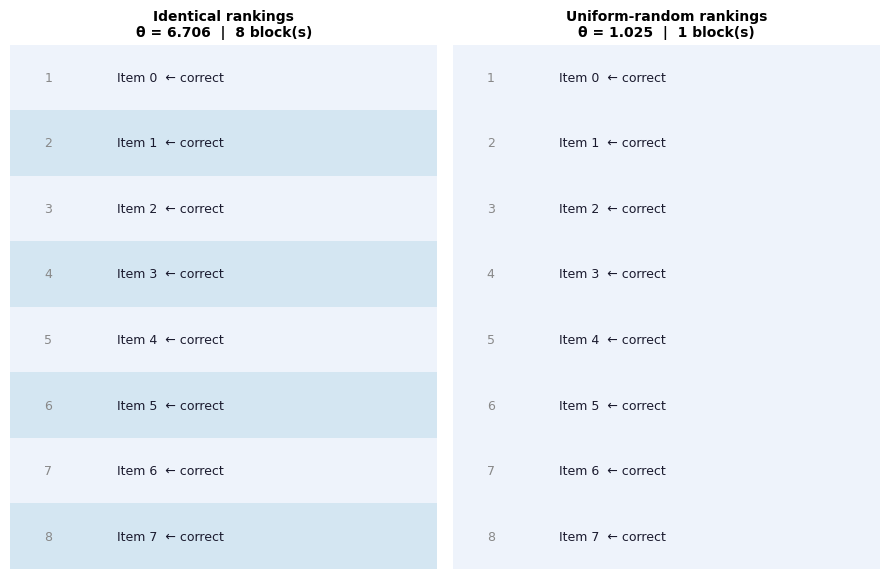

In [23]:
block_bg = ["#eef3fb", "#d4e6f2"]

def draw_block_table(ax, blocks, n_items, title, theta):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_items)
    ax.axis("off")
    ax.set_title(f"{title}\nθ = {theta:.3f}  |  {len(blocks)} block(s)",
                 fontsize=10, fontweight="bold", pad=6)
    rank = 0
    for b_idx, block in enumerate(blocks):
        bg = block_bg[b_idx % 2]
        for item in block:
            y0    = n_items - rank - 1
            y_mid = y0 + 0.5
            ax.add_patch(plt.Rectangle((0, y0), 1, 1, facecolor=bg, edgecolor="none"))
            ax.text(0.08, y_mid, str(rank + 1), fontsize=9,
                    color="#888888", ha="left", va="center")
            label_txt = f"Item {item}" + ("  ← correct" if rank == item else "")
            ax.text(0.25, y_mid, label_txt, fontsize=9,
                    color="#1a1a2e", ha="left", va="center")
            rank += 1


fig, axes = plt.subplots(1, 2, figsize=(9, N_ITEMS * 0.55 + 1.5))

for ax, result, title in zip(
    axes,
    [result_id, result_rnd],
    ["Identical rankings", "Uniform-random rankings"],
):
    blocks = result["clusters"][0]["blocks"]
    theta  = result["clusters"][0]["theta"]
    draw_block_table(ax, blocks, N_ITEMS, title, theta)

fig.tight_layout()
plt.show()

## θ posterior chains

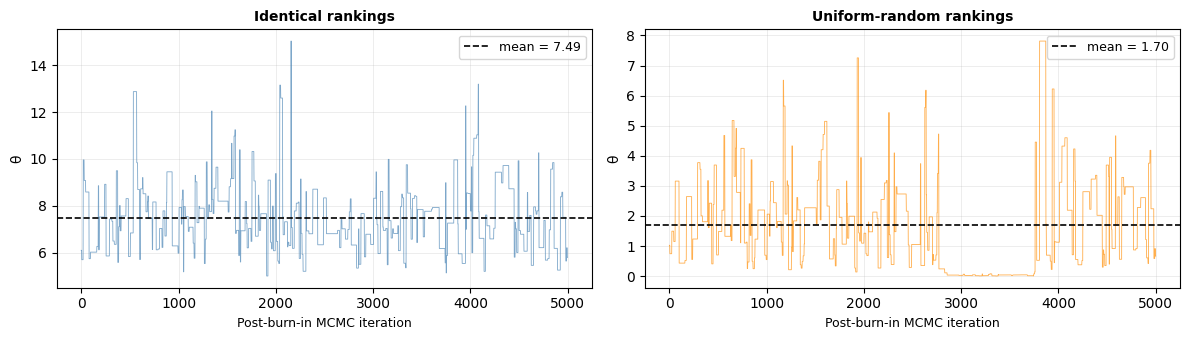

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for ax, samples, label, color in zip(
    axes,
    [samples_id, samples_rnd],
    ["Identical rankings", "Uniform-random rankings"],
    ["steelblue", "darkorange"],
):
    # theta_samples shape: [T][C]  — extract cluster-0 chain across all T stored draws
    chain = [samples.theta_samples[t][0] for t in range(len(samples.theta_samples))]
    ax.plot(chain, lw=0.6, alpha=0.7, color=color)
    ax.axhline(np.mean(chain), color="black", lw=1.2, ls="--",
               label=f"mean = {np.mean(chain):.2f}")
    ax.set_xlabel("Post-burn-in MCMC iteration", fontsize=9)
    ax.set_ylabel("θ", fontsize=10)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(lw=0.4, alpha=0.4)

fig.tight_layout()
plt.show()


## Scaling study — blocks recovered vs number of assessors (truly random data)

With genuinely random rankings (independent uniform permutations, no pairing), each pairwise preference is only *approximately* 0.5 — there is sampling noise of order $1/\sqrt{N}$. The model may exploit that noise to produce multiple blocks. We sweep N to find how large the dataset needs to be before the MAP consensus reliably collapses to 1 block.


In [29]:
# Sweep over rater counts — purely random (no pairing), multiple seeds per size
# so we can see whether the result is consistent or seed-dependent.
N_SIZES = [10, 25, 50, 100, 200, 500, 1000, 2000]
N_SEEDS = 3   # repeat each size with different random seeds

scaling_results = []

for n_raters in N_SIZES:
    for trial_seed in range(N_SEEDS):
        rng_s = random.Random(SEED * 100 + n_raters + trial_seed)
        ds_rnd = []
        for _ in range(n_raters):
            perm = list(range(N_ITEMS))
            rng_s.shuffle(perm)
            ds_rnd.append(perm)

        res, _ = run_single_cluster(ds_rnd, N_ITEMS,
                                    f"rnd n={n_raters} seed={trial_seed}", seed=trial_seed)
        n_blocks = len(res["clusters"][0]["blocks"])
        theta    = res["clusters"][0]["theta"]
        # measure actual max deviation from 0.5 in the pairwise matrix
        P = pairwise_preference(ds_rnd, N_ITEMS)
        off = P[~np.eye(N_ITEMS, dtype=bool)]
        max_dev = float(np.abs(off - 0.5).max())

        scaling_results.append({
            "n_raters":   n_raters,
            "trial_seed": trial_seed,
            "n_blocks":   n_blocks,
            "theta":      round(theta, 3),
            "max_dev":    round(max_dev, 3),
        })
        print(f"  n={n_raters:5d}  seed={trial_seed}  blocks={n_blocks}  "
              f"theta={theta:.3f}  max_dev={max_dev:.3f}")

import pandas as pd
df_scale = pd.DataFrame(scaling_results)
print()
print(df_scale.to_string(index=False))


[rnd n=10 seed=0]  elapsed=10.6s  logp_chain=-103.92  logp_refined=-103.92
  n=   10  seed=0  blocks=4  theta=0.278  max_dev=0.400
[rnd n=10 seed=1]  elapsed=10.8s  logp_chain=-105.51  logp_refined=-105.51
  n=   10  seed=1  blocks=4  theta=0.226  max_dev=0.200
[rnd n=10 seed=2]  elapsed=9.3s  logp_chain=-103.36  logp_refined=-103.36
  n=   10  seed=2  blocks=3  theta=0.350  max_dev=0.400
[rnd n=25 seed=0]  elapsed=9.1s  logp_chain=-265.00  logp_refined=-265.00
  n=   25  seed=0  blocks=3  theta=0.171  max_dev=0.180
[rnd n=25 seed=1]  elapsed=10.2s  logp_chain=-262.92  logp_refined=-262.92
  n=   25  seed=1  blocks=5  theta=0.194  max_dev=0.260
[rnd n=25 seed=2]  elapsed=9.4s  logp_chain=-262.93  logp_refined=-262.93
  n=   25  seed=2  blocks=4  theta=0.169  max_dev=0.260
[rnd n=50 seed=0]  elapsed=8.1s  logp_chain=-524.22  logp_refined=-524.22
  n=   50  seed=0  blocks=6  theta=0.156  max_dev=0.220
[rnd n=50 seed=1]  elapsed=8.1s  logp_chain=-526.75  logp_refined=-526.73
  n=   50  se

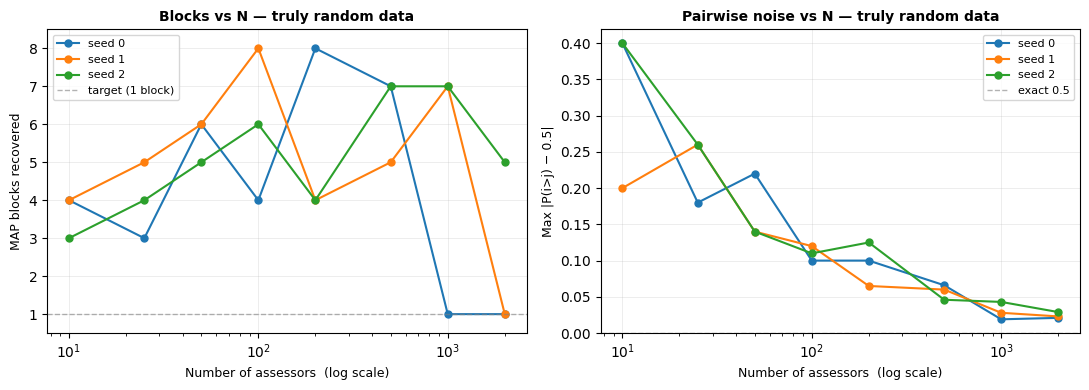

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = plt.get_cmap("tab10")

for trial_seed, grp in df_scale.groupby("trial_seed"):
    ax1.plot(grp["n_raters"], grp["n_blocks"], "o-",
             color=colors(trial_seed), lw=1.5, markersize=5,
             label=f"seed {trial_seed}")
    ax2.plot(grp["n_raters"], grp["max_dev"], "o-",
             color=colors(trial_seed), lw=1.5, markersize=5,
             label=f"seed {trial_seed}")

ax1.axhline(1, color="grey", lw=1, ls="--", alpha=0.6, label="target (1 block)")
ax1.set_xscale("log")
ax1.set_xlabel("Number of assessors  (log scale)", fontsize=9)
ax1.set_ylabel("MAP blocks recovered", fontsize=9)
ax1.set_title("Blocks vs N — truly random data", fontsize=10, fontweight="bold")
ax1.set_yticks(range(1, N_ITEMS + 1))
ax1.set_ylim(0.5, N_ITEMS + 0.5)
ax1.legend(fontsize=8)
ax1.grid(lw=0.4, alpha=0.4)

ax2.axhline(0, color="grey", lw=1, ls="--", alpha=0.6, label="exact 0.5")
ax2.set_xscale("log")
ax2.set_xlabel("Number of assessors  (log scale)", fontsize=9)
ax2.set_ylabel("Max |P(i>j) − 0.5|", fontsize=9)
ax2.set_title("Pairwise noise vs N — truly random data", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(lw=0.4, alpha=0.4)

fig.tight_layout()
plt.show()


## Why does θ appear high for 1 block and low for many blocks on random data?

This is a subtle but important point. The MAP jointly optimises *both* blocks and θ, and the two interact through the normalisation constant $Z^*$.

The log-posterior (from `model/priors.py`) is:

$$\log p(\text{blocks},\,\theta \mid \text{data}) = -\theta S - N\,\log Z^*(\text{sizes},\,\theta) + \text{prior}(\theta)$$

**Key fact about $Z^*$:**

$$\log Z^*(\text{sizes},\,\theta) = \sum_k \log(s_k!) + \log[n]_q! - \sum_k \log[s_k]_q!, \quad q = e^{-\theta}$$

**Special case — one big block** ($s_1 = n$):

$$\log Z^*_{\text{1 block}} = \log(n!) + \log[n]_q! - \log[n]_q! = \log(n!)$$

This is **constant in θ** — the likelihood does not depend on θ at all when there is a single block.

**Special case — all singletons** ($s_k = 1$):

$$\log Z^*_{\text{singletons}} = 0 + \log[n]_q! - 0 = \log[n]_q!$$

This *decreases toward 0* as θ → ∞ (q → 0), making the likelihood larger at high θ (if $S = 0$).

**This gives the two distinct behaviours:**

| Data | MAP blocks | Why | MAP θ |
|---|---|---|---|
| Identical | All singletons ($S=0$) | Singletons have $Z^* = [n]_q! \ll n!$ at high θ → high likelihood | High (≈7): data drives θ up |
| Paired-random | 1 block ($S=0$) | 1 block has $Z^* = n!$ constant → likelihood flat in θ | **Unidentified**: θ drifts to prior mode (≈1–2) |
| Noisy random | Multiple blocks | Exploiting noise reduces $S$, but requires small θ to tolerate residual disagreements | Low: model can't raise θ without hurting the noisy fit |

So your intuition is correct as a statement about the *model*: at small θ it is more likely to produce ties. But in the *MAP*, θ is not fixed — it is co-optimised with the block structure. The 1-block result does **not** mean θ is small; it means θ is simply **not informed by the data at all** (the likelihood is flat in θ for 1 block), so θ just reflects the prior.


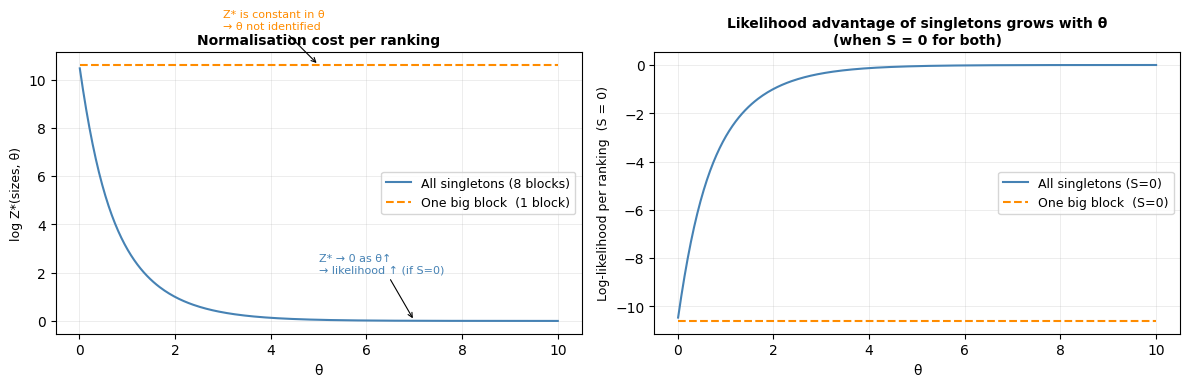

At θ=0:   logZ_singletons=10.465,  logZ_one_block=10.605  (both = log(8!) = 10.605)
At θ=5:   logZ_singletons=0.048,  logZ_one_block=10.605
At θ=10:  logZ_singletons=0.000,  logZ_one_block=10.605

Conclusion: one big block has the SAME Z* regardless of θ.
Singletons have LOWER Z* at high θ → higher likelihood when S=0 (identical data).
For random data with S=0, one big block is preferred because Z*_one_block ≈ Z*_singletons at low θ,
but the data has no signal pushing θ up → θ floats to prior; 1 block and singletons are indistinguishable at θ≈0.


In [31]:
import math
from model.priors import log_Z_star_from_sizes

thetas = np.linspace(0.01, 10, 300)
n = N_ITEMS

logZ_singletons = np.array([log_Z_star_from_sizes([1]*n, t) for t in thetas])
logZ_one_block  = np.array([log_Z_star_from_sizes([n],   t) for t in thetas])

# Log-likelihood per ranking for each structure, assuming S=0 (best-case)
# LL = -theta*0 - logZ = -logZ
ll_singletons = -logZ_singletons
ll_one_block  = -logZ_one_block

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: log Z* ──────────────────────────────────────────────────────────────
axes[0].plot(thetas, logZ_singletons, label=f"All singletons ({n} blocks)", color="steelblue")
axes[0].plot(thetas, logZ_one_block,  label="One big block  (1 block)",    color="darkorange", ls="--")
axes[0].set_xlabel("θ", fontsize=10)
axes[0].set_ylabel("log Z*(sizes, θ)", fontsize=9)
axes[0].set_title("Normalisation cost per ranking", fontsize=10, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(lw=0.4, alpha=0.4)
axes[0].annotate("Z* is constant in θ\n→ θ not identified",
                 xy=(5, logZ_one_block[150]), xytext=(3, logZ_one_block[150] + 1.5),
                 arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=8, color="darkorange")
axes[0].annotate("Z* → 0 as θ↑\n→ likelihood ↑ (if S=0)",
                 xy=(7, logZ_singletons[210]), xytext=(5, logZ_singletons[210] + 2),
                 arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=8, color="steelblue")

# ── Right: log-likelihood per ranking (S=0) ───────────────────────────────────
axes[1].plot(thetas, ll_singletons, label="All singletons (S=0)", color="steelblue")
axes[1].plot(thetas, ll_one_block,  label="One big block  (S=0)", color="darkorange", ls="--")
axes[1].set_xlabel("θ", fontsize=10)
axes[1].set_ylabel("Log-likelihood per ranking  (S = 0)", fontsize=9)
axes[1].set_title("Likelihood advantage of singletons grows with θ\n(when S = 0 for both)", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(lw=0.4, alpha=0.4)

fig.tight_layout()
plt.show()

print(f"At θ=0:   logZ_singletons={logZ_singletons[0]:.3f},  logZ_one_block={logZ_one_block[0]:.3f}  (both = log({n}!) = {math.lgamma(n+1):.3f})")
print(f"At θ=5:   logZ_singletons={logZ_singletons[149]:.3f},  logZ_one_block={logZ_one_block[149]:.3f}")
print(f"At θ=10:  logZ_singletons={logZ_singletons[-1]:.3f},  logZ_one_block={logZ_one_block[-1]:.3f}")
print()
print("Conclusion: one big block has the SAME Z* regardless of θ.")
print("Singletons have LOWER Z* at high θ → higher likelihood when S=0 (identical data).")
print("For random data with S=0, one big block is preferred because Z*_one_block ≈ Z*_singletons at low θ,")
print("but the data has no signal pushing θ up → θ floats to prior; 1 block and singletons are indistinguishable at θ≈0.")


## Why Z\* becomes constant, and what drives θ down

### 1 — Why Z\* is flat in θ when there is one block

The normalising constant for a consensus $\rho$ with block sizes $(s_1, \ldots, s_K)$ is (eq. 12 in the paper):

$$Z^*(\rho, \theta) = P(\mathbf{s}) \cdot \frac{[n]_{e^{-\theta}}!}{\prod_{k=1}^{K} [s_k]_{e^{-\theta}}!}$$

where $[m]_q! = \prod_{j=1}^{m}(1 + q + q^2 + \cdots + q^{j-1})$ is the $q$-factorial and $P(\mathbf{s}) = \prod_k s_k!$ is the within-block permutation count.

When there is **one block** of size $n$, every $[s_k]_q!$ term in the denominator equals $[n]_q!$, which cancels exactly with the numerator:

$$Z^*_{\text{1 block}} = n! \cdot \frac{[n]_q!}{[n]_q!} = n!$$

The $q$-factorial terms cancel completely, and $n!$ is a constant that does not depend on $\theta$. This makes the Mallows likelihood

$$\ell(\theta) = -\theta \cdot S - \log Z^*$$

**entirely flat in $\theta$** when $S = 0$ (which is guaranteed when there is only one block, since the distance $d(r, \rho)$ counts only cross-block inversions). The data carry no information about $\theta$, so the posterior is driven entirely by the prior $\theta \sim \text{Gamma}(a_\theta, b_\theta)$, whose mode is $(a_\theta - 1)/b_\theta$. With the default $a_\theta = 2, b_\theta = 1$ this gives a mode of 1.

### 2 — What drives θ down in a multi-block state on noisy data

When the sampler is in a multi-block state on random data, there are cross-block pairs that some assessors rank in the wrong order, contributing a positive total distance $S > 0$. The log-posterior is:

$$\log p(\theta \mid \cdot) = -\theta S - N \log Z^*(\mathbf{s}, \theta) + (a_\theta - 1)\log\theta - b_\theta\theta$$

Two opposing forces act on $\theta$:

- **Upward pull (Z\* term):** $Z^*$ decreases monotonically as $\theta \uparrow$ (the $q$-factorials shrink), so $-N \log Z^*$ increases — favouring larger $\theta$.
- **Downward pull (distance term):** $-\theta S$ decreases linearly as $\theta \uparrow$, penalising any disagreement $S > 0$ more heavily.

At small $\theta$ the $Z^*$ term dominates; at large $\theta$ the $S$ term dominates. The MAP balances these at a value that falls below the prior mode precisely because the data force $S > 0$. The noisier the data — and the more the multi-block partition artificially creates cross-block disagreements — the lower the balanced $\theta$ must be.

In short: **the distance penalty $-\theta S$ is a brake** on $\theta$. With one block $S \equiv 0$ and the brake is off; $\theta$ coasts to the prior. With multiple blocks on random data, $S > 0$ and the brake pulls $\theta$ well below 1.

---
## Simulation sweep: blocks/n and θ as a function of items, assessors, and noise

For each combination of `(n_items, n_assessors, θ_true)` we:
1. Generate data from a single-block Mallows consensus with dispersion `θ_true` (θ_true=0 → pure random permutations).
2. Fit the single-cluster model.
3. Record the posterior MAP `blocks/n_items` and `θ`.

In [11]:
import pandas as pd
from helper_functions.Generate_mixture_data import sample_mallows_tied_batch

# ── Grid ──────────────────────────────────────────────────────────────────────
SWEEP_N_ITEMS      = [20, 50, 100]
SWEEP_N_ASSESSORS  = [20, 50, 100, 200, 500, 1000]
SWEEP_THETA_TRUE   = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]   # 0 = pure random
SWEEP_SEEDS        = [0, 1, 2]

SWEEP_N_ITER  = 8_000
SWEEP_BURN_IN = 4_000

def run_sweep_cell(n_items, n_assessors, theta_true, seed):
    """Generate Mallows data and fit single-cluster model. Returns (blocks/n, theta_map)."""
    rng_data = np.random.default_rng(seed)
    consensus = [[i] for i in range(n_items)]   # strict order 0>1>...>n-1

    if theta_true == 0.0:
        # theta=0 → uniform over all permutations
        data = [list(rng_data.permutation(n_items)) for _ in range(n_assessors)]
    else:
        data = sample_mallows_tied_batch(consensus, theta_true, rng_data, n_samples=n_assessors)

    # Borda init
    score = np.zeros(n_items)
    for r in data:
        for pos, item in enumerate(r):
            score[item] += (n_items - 1 - pos)
    order   = list(np.argsort(-score))
    blocks0 = [[item] for item in order]
    init_cl = ClusterParams(blocks=blocks0, theta=1.0, gamma=1.0, delta=0.5)

    model = MixtureRankingModel(
        rankings      = data,
        n_items       = n_items,
        init_clusters = [init_cl],
        seed          = seed,
        verbose       = False,
    )
    _, samples = model.run_mcmc(
        n_iter                   = SWEEP_N_ITER,
        burn_in                  = SWEEP_BURN_IN,
        thin                     = 1,
        save_samples             = True,
        save_theta               = True,
        use_py_prior             = False,
        include_order_prior      = False,
        theta_jump               = 5,
        n_item_moves_per_cluster = 3,
    )
    result       = model.find_map(samples, refine=True, verbose=False)
    n_blocks_map = len(result["clusters"][0]["blocks"])
    theta_map    = result["clusters"][0]["theta"]
    return n_blocks_map / n_items, theta_map


# ── Run sweep ─────────────────────────────────────────────────────────────────
sweep_records = []
total = len(SWEEP_N_ITEMS) * len(SWEEP_N_ASSESSORS) * len(SWEEP_THETA_TRUE) * len(SWEEP_SEEDS)
done  = 0

for n_items in SWEEP_N_ITEMS:
    for n_assessors in SWEEP_N_ASSESSORS:
        for theta_true in SWEEP_THETA_TRUE:
            for seed in SWEEP_SEEDS:
                rel_blocks, theta_map = run_sweep_cell(n_items, n_assessors, theta_true, seed)
                sweep_records.append(dict(
                    n_items     = n_items,
                    n_assessors = n_assessors,
                    theta_true  = theta_true,
                    seed        = seed,
                    rel_blocks  = rel_blocks,
                    theta_map   = theta_map,
                ))
                done += 1
                if done % 30 == 0 or done == total:
                    print(f"  {done}/{total}  last: n={n_items}, N={n_assessors}, θ_true={theta_true:.1f}, seed={seed} "
                          f"→ blocks/n={rel_blocks:.2f}, θ_map={theta_map:.3f}")

df_sweep = pd.DataFrame(sweep_records)
print(f"\nDone. {len(df_sweep)} rows.")


  30/324  last: n=20, N=50, θ_true=1.0, seed=2 → blocks/n=0.95, θ_map=1.020
  60/324  last: n=20, N=200, θ_true=0.2, seed=2 → blocks/n=0.70, θ_map=0.241
  90/324  last: n=20, N=500, θ_true=4.0, seed=2 → blocks/n=1.00, θ_map=4.094
  120/324  last: n=50, N=20, θ_true=1.0, seed=2 → blocks/n=0.80, θ_map=1.084
  150/324  last: n=50, N=100, θ_true=0.2, seed=2 → blocks/n=0.72, θ_map=0.246
  180/324  last: n=50, N=200, θ_true=4.0, seed=2 → blocks/n=1.00, θ_map=4.120
  210/324  last: n=50, N=1000, θ_true=1.0, seed=2 → blocks/n=1.00, θ_map=0.996
  240/324  last: n=100, N=50, θ_true=0.2, seed=2 → blocks/n=0.67, θ_map=0.261
  270/324  last: n=100, N=100, θ_true=4.0, seed=2 → blocks/n=1.00, θ_map=4.136
  300/324  last: n=100, N=500, θ_true=1.0, seed=2 → blocks/n=1.00, θ_map=0.997
  324/324  last: n=100, N=1000, θ_true=4.0, seed=2 → blocks/n=1.00, θ_map=4.020

Done. 324 rows.


Using 324 sweep records.


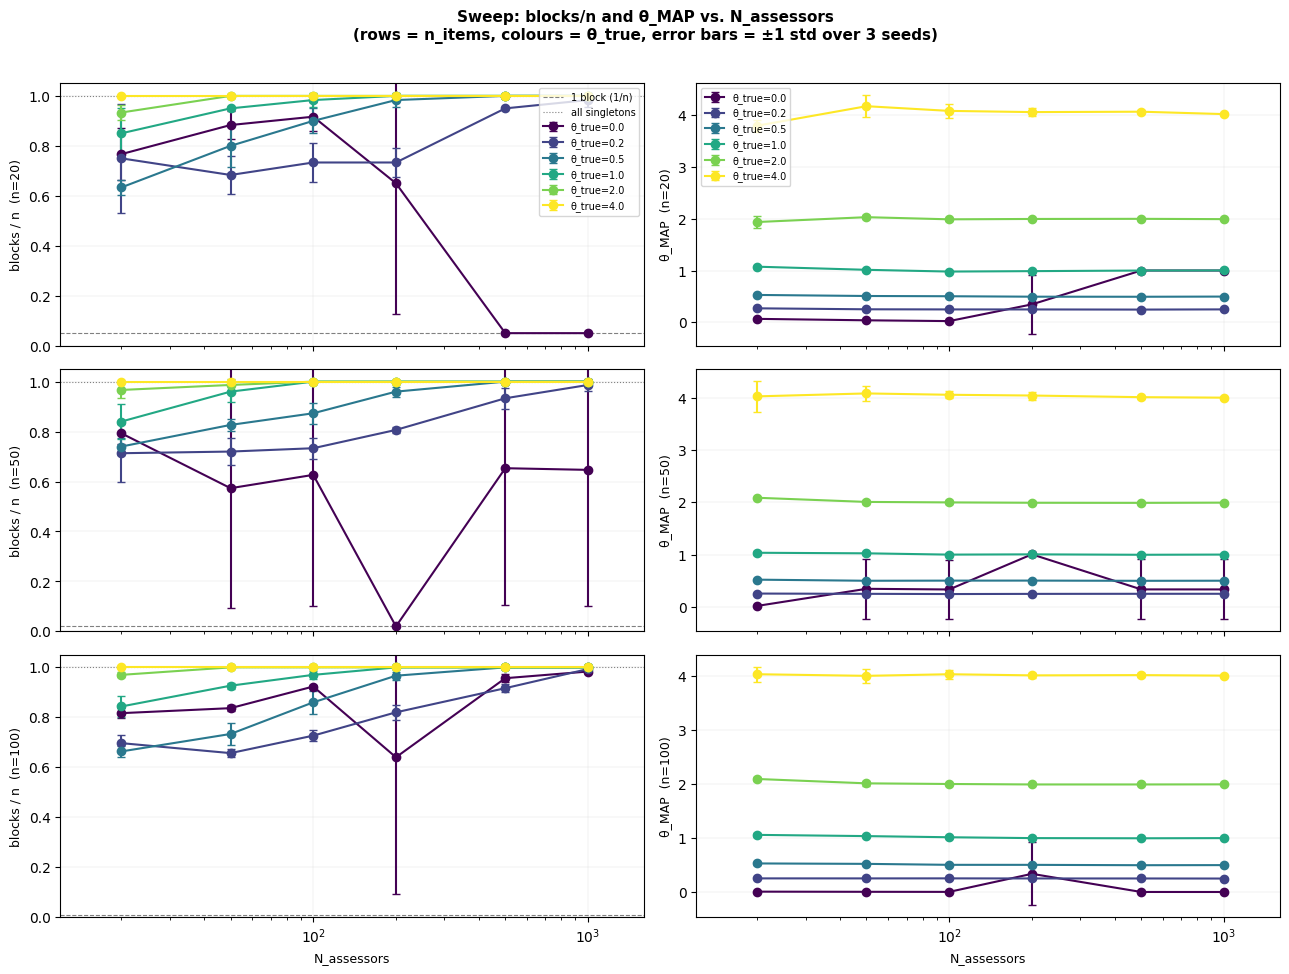

In [12]:
import pandas as pd
df_sweep = pd.DataFrame(sweep_records)
print(f"Using {len(df_sweep)} sweep records.")

# ── Aggregate: mean ± std over seeds ─────────────────────────────────────────
df_agg = (
    df_sweep
    .groupby(["n_items", "n_assessors", "theta_true"])
    .agg(
        rel_blocks_mean = ("rel_blocks",  "mean"),
        rel_blocks_std  = ("rel_blocks",  "std"),
        theta_map_mean  = ("theta_map",   "mean"),
        theta_map_std   = ("theta_map",   "std"),
    )
    .reset_index()
)

# ── Colour palette: one shade per theta_true ──────────────────────────────────
import matplotlib.cm as mcm
theta_vals  = sorted(df_agg["theta_true"].unique())
n_theta     = len(theta_vals)
palette     = {t: mcm.viridis(i / (n_theta - 1)) for i, t in enumerate(theta_vals)}

fig, axes = plt.subplots(
    len(SWEEP_N_ITEMS), 2,
    figsize=(13, 3.2 * len(SWEEP_N_ITEMS)),
    sharex="col",
)
fig.suptitle("Sweep: blocks/n and θ_MAP vs. N_assessors\n"
             "(rows = n_items, colours = θ_true, error bars = ±1 std over 3 seeds)",
             fontsize=11, fontweight="bold", y=1.01)

x_min = min(SWEEP_N_ASSESSORS) * 0.6
x_max = max(SWEEP_N_ASSESSORS) * 1.6

for row_idx, n_items in enumerate(SWEEP_N_ITEMS):
    ax_b = axes[row_idx, 0]
    ax_t = axes[row_idx, 1]
    sub   = df_agg[df_agg["n_items"] == n_items]

    for theta_true in theta_vals:
        s    = sub[sub["theta_true"] == theta_true].sort_values("n_assessors")
        col  = palette[theta_true]
        lbl  = f"θ_true={theta_true:.1f}"
        xs   = s["n_assessors"].values

        ax_b.errorbar(xs, s["rel_blocks_mean"], yerr=s["rel_blocks_std"],
                      marker="o", color=col, label=lbl, capsize=3, linewidth=1.5)
        ax_t.errorbar(xs, s["theta_map_mean"],  yerr=s["theta_map_std"],
                      marker="o", color=col, label=lbl, capsize=3, linewidth=1.5)

    ax_b.axhline(1/n_items, color="gray", ls="--", lw=0.8, label="1 block (1/n)")
    ax_b.axhline(1.0,        color="gray", ls=":",  lw=0.8, label="all singletons")
    ax_b.set_ylabel(f"blocks / n  (n={n_items})", fontsize=9)
    ax_b.set_ylim(0, 1.05)
    ax_b.set_xscale("log")
    ax_b.set_xlim(x_min, x_max)
    ax_b.grid(lw=0.3, alpha=0.4)

    ax_t.set_ylabel(f"θ_MAP  (n={n_items})", fontsize=9)
    ax_t.set_xscale("log")
    ax_t.set_xlim(x_min, x_max)
    ax_t.grid(lw=0.3, alpha=0.4)

    if row_idx == 0:
        ax_b.legend(fontsize=7, loc="upper right")
        ax_t.legend(fontsize=7, loc="upper left")

for ax in axes[-1]:
    ax.set_xlabel("N_assessors", fontsize=9)

fig.tight_layout()
plt.show()
